# 01 — EDA on ISCX-URL2016 numeric features

**Project:** AI-based Malicious URL Detection
**Datasets explored:**

- `data/All.csv` — full feature set (79 numeric features + target `URL_Type_obf_Type`).
- `data/All_BestFirst.csv` — 8 features pre-selected with a Best-First search + `class`.
- `data/All_Infogain.csv` — 12 features pre-selected by Information Gain + `class`.

**Task:** 5-class classification (`benign`, `Defacement`, `phishing`, `malware`, `spam`) — **well balanced** (~1.2 : 1), unlike raw-URL corpora like `malicious_phish.csv`.

**Goal of this notebook:** understand the tabular features, quantify data-quality issues (the `-1` sentinels, the string `"NaN"`), compare the two pre-selected feature subsets, visualize class separability (PCA / t-SNE), and persist a cleaned `All.csv` ready for the modelling notebooks.

## Section 1 — Setup & imports

In [1]:
# Core libs + stats / dim-reduction helpers
import os
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Reproducibility + plotting defaults
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.dpi"] = 120
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Resolve project root robustly (works whether cwd is project root or notebooks/)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Paths
DATA_DIR = PROJECT_ROOT / "data"
ALL_PATH = DATA_DIR / "All.csv"
BF_PATH = DATA_DIR / "All_BestFirst.csv"
IG_PATH = DATA_DIR / "All_Infogain.csv"
CLEAN_PATH = DATA_DIR / "All_clean.csv"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Target column names differ between files -> normalize to this
TARGET_COL = "class"

# Early fail with clear message if files are missing
required_files = [ALL_PATH, BF_PATH, IG_PATH]
missing_files = [p for p in required_files if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing required dataset files:\n" + "\n".join(f"- {p}" for p in missing_files)
    )

print(f"Seed:          {RANDOM_SEED}")
print(f"Project root:  {PROJECT_ROOT}")
print(f"Output dir:    {OUTPUT_DIR}")

Seed:          42
Project root:  /home/youcef/Desktop/url_detection
Output dir:    /home/youcef/Desktop/url_detection/notebooks/outputs/eda


## Section 2 — Load the three datasets & normalize target name

In [2]:
# Load everything. `low_memory=False` avoids mixed-dtype warnings from the "NaN" strings.
df_all = pd.read_csv(ALL_PATH, low_memory=False)
df_bf = pd.read_csv(BF_PATH, low_memory=False)
df_ig = pd.read_csv(IG_PATH, low_memory=False)

# Normalize the target column name: All.csv uses `URL_Type_obf_Type`, the others use `class`.
df_all = df_all.rename(columns={"URL_Type_obf_Type": TARGET_COL})

print("Shapes:")
print(f"  All.csv            -> {df_all.shape}")
print(f"  All_BestFirst.csv  -> {df_bf.shape}")
print(f"  All_Infogain.csv   -> {df_ig.shape}")

print(f"\nAll.csv columns ({len(df_all.columns)}): {list(df_all.columns)}")

Shapes:
  All.csv            -> (36707, 80)
  All_BestFirst.csv  -> (36694, 9)
  All_Infogain.csv   -> (36417, 13)

All.csv columns (80): ['Querylength', 'domain_token_count', 'path_token_count', 'avgdomaintokenlen', 'longdomaintokenlen', 'avgpathtokenlen', 'tld', 'charcompvowels', 'charcompace', 'ldl_url', 'ldl_domain', 'ldl_path', 'ldl_filename', 'ldl_getArg', 'dld_url', 'dld_domain', 'dld_path', 'dld_filename', 'dld_getArg', 'urlLen', 'domainlength', 'pathLength', 'subDirLen', 'fileNameLen', 'this.fileExtLen', 'ArgLen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'argPathRatio', 'executable', 'isPortEighty', 'NumberofDotsinURL', 'ISIpAddressInDomainName', 'CharacterContinuityRate', 'LongestVariableValue', 'URL_DigitCount', 'host_DigitCount', 'Directory_DigitCount', 'File_name_DigitCount', 'Extension_DigitCount', 'Query_DigitCount', 'URL_Letter_Count', 'host_letter_count', 'Directory_LetterCount', 'Filename_LetterCount', 'Extension_LetterCount

In [3]:
# Quick peek at each dataset
print("=== All.csv head ===")
display(df_all.head(3))

print("=== All_BestFirst.csv head ===")
display(df_bf.head(3))

print("=== All_Infogain.csv head ===")
display(df_ig.head(3))

=== All.csv head ===


,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,class
0,0,4,5,5.5,14,4.4,4,8,3,0,...,1,0,-1,0.726298,0.784493,0.894886,0.850608,NaN,-1.0,Defacement
1,0,4,5,5.5,14,6.0,4,12,4,0,...,0,0,-1,0.688635,0.784493,0.814725,0.859793,0.0,-1.0,Defacement
2,0,4,5,5.5,14,5.8,4,12,5,0,...,0,0,-1,0.695049,0.784493,0.814725,0.801880,0.0,-1.0,Defacement


=== All_BestFirst.csv head ===


,domain_token_count,executable,NumberofDotsinURL,Arguments_LongestWordLength,NumberRate_Domain,NumberRate_FileName,NumberRate_AfterPath,Entropy_Domain,class
0,19,0,18,-1,0.041,0.656,-1.0,0.612,phishing
1,15,0,15,-1,0.083,0.000,-1.0,0.633,phishing
2,15,0,15,-1,0.083,0.000,-1.0,0.633,phishing


=== All_Infogain.csv head ===


,avgpathtokenlen,pathurlRatio,ArgUrlRatio,argDomanRatio,domainUrlRatio,pathDomainRatio,argPathRatio,CharacterContinuityRate,NumberRate_URL,NumberRate_FileName,NumberRate_AfterPath,Entropy_Domain,class
0,105.0,0.876,0.008,0.087,0.095,9.174,0.01,0.435,0.199,0.219,-1.0,0.904,phishing
1,66.0,0.874,0.009,0.091,0.096,9.136,0.01,0.682,0.257,0.293,-1.0,0.870,phishing
2,66.0,0.874,0.009,0.091,0.096,9.136,0.01,0.682,0.000,0.000,-1.0,0.870,phishing


## Section 3 — Data quality

Things to check for this dataset:

1. **Real NaN values** — standard `df.isna()` check.
2. **String `"NaN"`** — the CSV literally contains the text `NaN` in `Entropy_Extension`. pandas should already coerce it to float NaN, but we verify.
3. **`-1` sentinels** — for URLs that have no filename / extension / query / port, the feature extractor writes `-1` instead of 0. That's a *meaningful signal* (absence) but also badly skews means/medians, so we quantify per feature.
4. **Exact duplicates** — rows where every feature + class is identical.
5. **Constant columns** — features with zero variance (useless for modelling).
6. **Class label capitalization** — `Defacement` is capitalized while the other four classes are lowercase. We surface it but don't fix it yet (model layer may want the raw labels).

In [4]:
# 1. Real NaN values per column (All.csv)
nan_counts = df_all.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
if nan_counts.empty:
    print("No real NaN values found in All.csv")
else:
    print("Columns with NaN values (All.csv):")
    print(nan_counts.to_string())

Columns with NaN values (All.csv):
NumberRate_Extension        10130
Entropy_DirectoryName        8468
avgpathtokenlen               280
Entropy_Filename              236
Entropy_Extension              40
NumberRate_DirectoryName       10
NumberRate_FileName            10
Entropy_Afterpath               6
NumberRate_AfterPath            3


In [5]:
# 2. Verify `"NaN"` strings (if any survived pandas' auto-parsing) + show Entropy_Extension distribution
print("Entropy_Extension dtype:", df_all["Entropy_Extension"].dtype)
print("Entropy_Extension — value counts of NaN/non-NaN:")
print(df_all["Entropy_Extension"].isna().value_counts())
print("Entropy_Extension sample values:")
print(df_all["Entropy_Extension"].dropna().head(5).to_list())

Entropy_Extension dtype: float64
Entropy_Extension — value counts of NaN/non-NaN:
Entropy_Extension
False    36667
True        40
Name: count, dtype: int64
Entropy_Extension sample values:
[0.0, 0.0, 0.0, 0.0, 0.0]


Features with any `-1` sentinel (26 of 79):
ISIpAddressInDomainName            100.00
isPortEighty                        99.96
SymbolCount_Afterpath               55.80
Entropy_Afterpath                   55.80
NumberRate_AfterPath                55.80
LongestVariableValue                55.26
Query_LetterCount                   55.26
Query_DigitCount                    55.26
Arguments_LongestWordLength         55.26
delimeter_Count                     55.26
Directory_DigitCount                30.64
Directory_LetterCount               30.64
SymbolCount_Directoryname           28.11
sub-Directory_LongestWordLength      5.59
SymbolCount_Extension                5.05
SymbolCount_FileName                 5.05
NumberRate_DirectoryName             5.05
NumberRate_FileName                  5.05
NumberRate_Extension                 5.05
Entropy_DirectoryName                5.05
Entropy_Filename                     5.05
Entropy_Extension                    5.05
Extension_LetterCount           

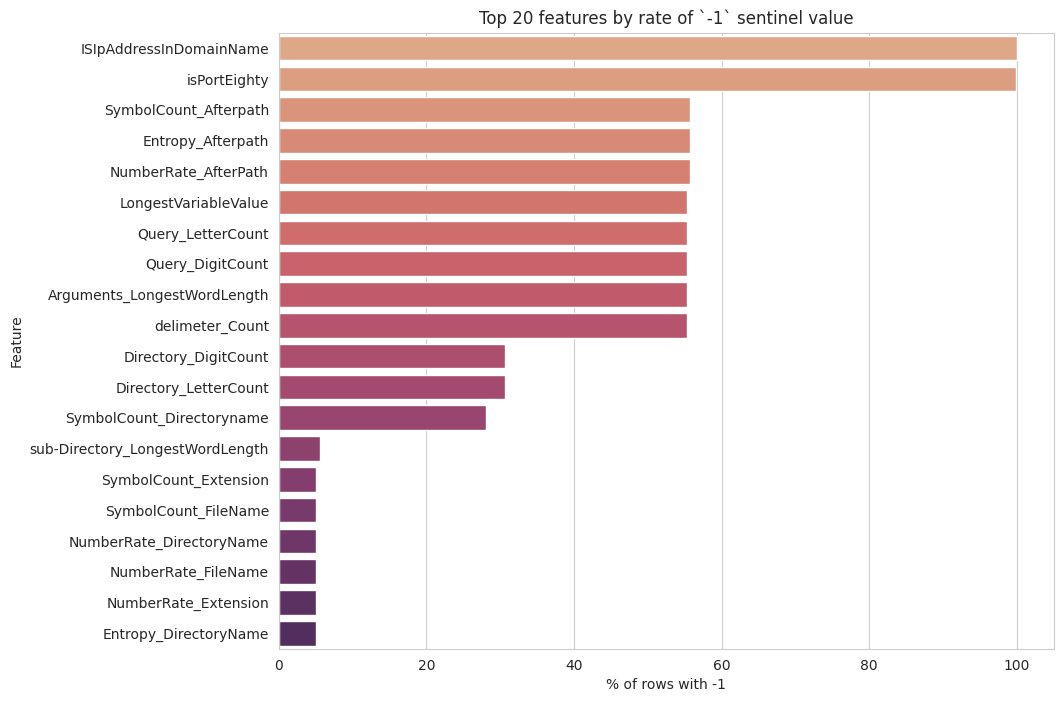

In [6]:
# 3. `-1` sentinel prevalence per feature (All.csv). Only numeric columns.
numeric_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()
minus_one_rate = (df_all[numeric_cols] == -1).mean() * 100
minus_one_rate = minus_one_rate[minus_one_rate > 0].sort_values(ascending=False)

print(f"Features with any `-1` sentinel ({len(minus_one_rate)} of {len(numeric_cols)}):")
print(minus_one_rate.round(2).to_string())

# Bar chart for the top 20 sentinel-heavy features
top_sentinel = minus_one_rate.head(20)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top_sentinel.values, y=top_sentinel.index, palette="flare", ax=ax)
ax.set_title("Top 20 features by rate of `-1` sentinel value")
ax.set_xlabel("% of rows with -1"); ax.set_ylabel("Feature")
plt.savefig(f"{OUTPUT_DIR}/03_minus_one_rate.png")
plt.show()

In [7]:
# 4. Exact duplicate rows (entire row incl. class)
n_dups_all = df_all.duplicated().sum()
n_dups_feat_only = df_all.drop(columns=[TARGET_COL]).duplicated().sum()
print(f"Exact duplicate rows (All.csv, incl. class):            {n_dups_all:,}")
print(f"Duplicate feature vectors (ignoring class, All.csv):    {n_dups_feat_only:,}")
if n_dups_feat_only > n_dups_all:
    print(f"  -> {n_dups_feat_only - n_dups_all:,} rows have identical features but DIFFERENT class -> label noise")

Exact duplicate rows (All.csv, incl. class):            9,754
Duplicate feature vectors (ignoring class, All.csv):    9,754


In [8]:
# 5. Constant (zero-variance) columns
constant_cols = [c for c in numeric_cols if df_all[c].nunique(dropna=True) <= 1]
print(f"Constant columns in All.csv: {constant_cols if constant_cols else 'none'}")

Constant columns in All.csv: ['ISIpAddressInDomainName']


In [9]:
# 6. Class label values (capitalization sanity check)
print("Unique class labels (All.csv):       ", sorted(df_all[TARGET_COL].unique()))
print("Unique class labels (All_BestFirst): ", sorted(df_bf[TARGET_COL].unique()))
print("Unique class labels (All_Infogain):  ", sorted(df_ig[TARGET_COL].unique()))

Unique class labels (All.csv):        ['Defacement', 'benign', 'malware', 'phishing', 'spam']
Unique class labels (All_BestFirst):  ['Defacement', 'benign', 'malware', 'phishing', 'spam']
Unique class labels (All_Infogain):   ['Defacement', 'benign', 'malware', 'phishing', 'spam']


## Section 4 — Class distribution

The 5 classes are nearly balanced here — no SMOTE needed in most cases. `class_weight="balanced"` will be enough. We still report F1-macro as the primary metric.

In [47]:
# Counts + percentages
class_counts = df_all[TARGET_COL].value_counts()
class_pct = (class_counts / len(df_all) * 100).round(2)
summary = pd.DataFrame({"count": class_counts, "percent": class_pct})
print("All.csv class distribution:")
print(summary)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f} : 1")

All.csv class distribution:
            count  percent
class                     
Defacement   7930    21.60
benign       7781    21.20
phishing     7586    20.67
malware      6712    18.29
spam         6698    18.25

Imbalance ratio (max/min): 1.18 : 1


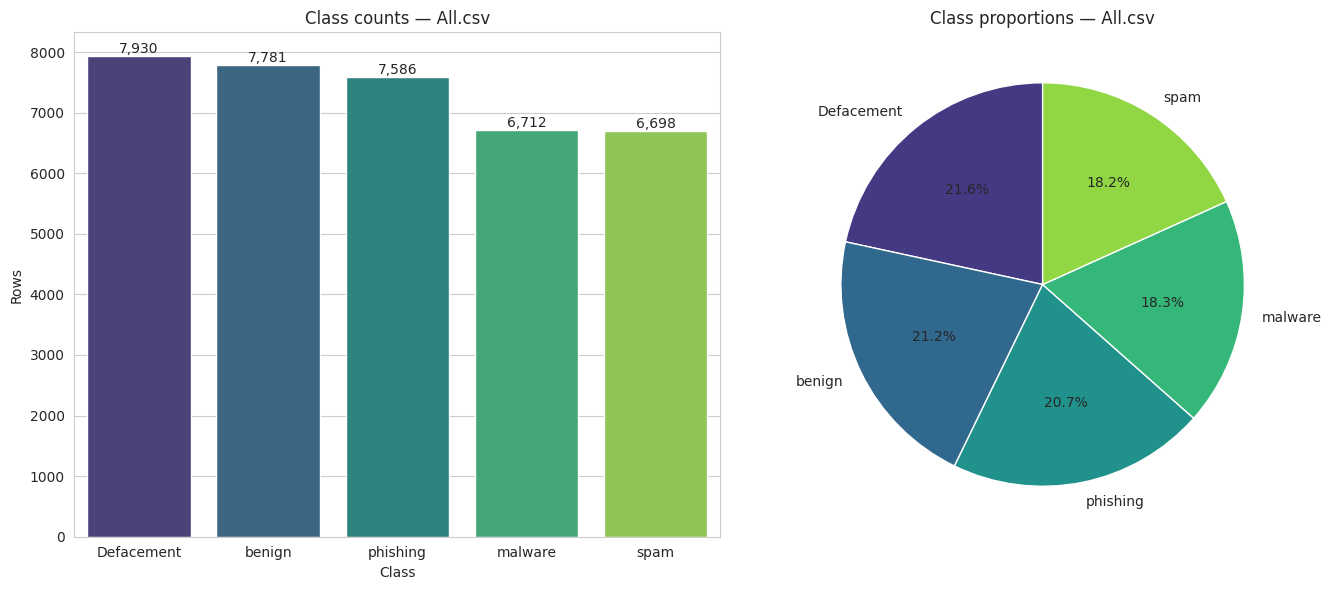

In [48]:
# Bar chart + pie chart side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", ax=axes[0])
axes[0].set_title("Class counts — All.csv")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Rows")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("viridis", n_colors=len(class_counts)),
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class proportions — All.csv")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_class_distribution.png")
plt.show()

In [49]:
# Compare counts across the three files — the BestFirst/Infogain subsets dropped a handful of rows
comparison = pd.DataFrame({
    "All.csv":           df_all[TARGET_COL].value_counts(),
    "All_BestFirst.csv": df_bf[TARGET_COL].value_counts(),
    "All_Infogain.csv":  df_ig[TARGET_COL].value_counts(),
})
comparison.loc["TOTAL"] = comparison.sum()
print("Per-class row counts across the three files:")
print(comparison)

Per-class row counts across the three files:
            All.csv  All_BestFirst.csv  All_Infogain.csv
class                                                   
Defacement     7930               7930              7930
benign         7781               7780              7776
phishing       7586               7575              7311
malware        6712               6711              6707
spam           6698               6698              6693
TOTAL         36707              36694             36417


## Section 5 — Feature overview (All.csv)

In [51]:
# describe() for all numeric features (safe skew/kurtosis to avoid warning spam on near-constant columns)
def safe_skew(s: pd.Series) -> float:
    x = s.dropna().values
    if len(x) < 3 or np.nanstd(x) == 0:
        return np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        return float(skew(x))

def safe_kurtosis(s: pd.Series) -> float:
    x = s.dropna().values
    if len(x) < 4 or np.nanstd(x) == 0:
        return np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        return float(kurtosis(x))

desc = df_all[numeric_cols].describe().T
desc["skew"] = df_all[numeric_cols].apply(safe_skew)
desc["kurtosis"] = df_all[numeric_cols].apply(safe_kurtosis)
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]]
print("Numeric feature summary (sorted by |skew| desc, top 20):")
display(desc.reindex(desc["skew"].abs().sort_values(ascending=False).index).head(20))

/home/lokmane/Desktop/url_detection_project/venv/lib/python3.11/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/lokmane/Desktop/url_detection_project/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1845: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


Numeric feature summary (sorted by |skew| desc, top 20):


/home/lokmane/Desktop/url_detection_project/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1845: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
dld_domain,36707.0,0.007328,0.253727,0.0,0.000,0.0,0.000000,25.00000,66.641147,5427.447947
isPortEighty,36707.0,-0.999619,0.019526,-1.0,-1.000,-1.0,-1.000000,0.00000,51.175472,2616.928953
ldl_domain,36707.0,0.116517,0.606963,0.0,0.000,0.0,0.000000,37.00000,30.564441,1525.647911
executable,36707.0,0.001389,0.037249,0.0,0.000,0.0,0.000000,1.00000,26.772121,714.746489
dld_filename,36707.0,0.061814,0.591369,0.0,0.000,0.0,0.000000,23.00000,15.409494,340.825159
ldl_filename,36707.0,0.182663,1.112706,0.0,0.000,0.0,0.000000,33.00000,11.816122,201.858229
LongestVariableValue,36707.0,17.444956,93.785703,-1.0,-1.000,-1.0,9.000000,1385.00000,8.912006,84.725062
Query_LetterCount,36707.0,15.715912,78.926758,-1.0,-1.000,-1.0,11.000000,1173.00000,8.773245,82.928320
Querylength,36707.0,21.908110,94.280669,0.0,0.000,0.0,19.000000,1385.00000,8.647329,81.271139
ldl_getArg,36707.0,2.395129,13.293604,0.0,0.000,0.0,0.000000,207.00000,8.541294,79.509736


In [52]:
# Variance ranking — features with very low variance (after standardization would be near-zero)
variances = df_all[numeric_cols].var().sort_values()
print("Lowest-variance features (potential drop candidates):")
print(variances.head(10).round(4).to_string())
print("\nHighest-variance features (dominate PCA without scaling):")
print(variances.tail(10).round(2).to_string())

Lowest-variance features (potential drop candidates):
ISIpAddressInDomainName    0.0000
isPortEighty               0.0004
executable                 0.0014
Entropy_URL                0.0024
Entropy_Domain             0.0044
NumberRate_URL             0.0092
NumberRate_Domain          0.0108
domainUrlRatio             0.0170
pathurlRatio               0.0254
CharacterContinuityRate    0.0260

Highest-variance features (dominate PCA without scaling):
URL_Letter_Count          6241.43
Extension_LetterCount     6425.54
LongestVariableValue      8795.76
Querylength               8888.84
LongestPathTokenLength    9054.66
urlLen                    9082.02
pathLength                9083.45
subDirLen                 9083.45
ArgLen                    9477.85
argPathRatio                  NaN


/home/lokmane/Desktop/url_detection_project/venv/lib/python3.11/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


## Section 6 — Feature distributions by class

We pick features known to be informative for URL classification (entropy / length / symbol / digit rates) and plot their distribution per class. Strong class-separation here means linear models will do fine; heavy overlap means we'll need non-linear methods.

In [53]:
# Hand-picked interpretable features that typically separate classes well on ISCX-URL2016
INTERESTING_FEATURES = [
    "urlLen", "domainlength", "pathLength",
    "NumberofDotsinURL", "Entropy_URL", "Entropy_Domain",
    "SymbolCount_URL", "URL_DigitCount", "URL_Letter_Count",
    "CharacterContinuityRate", "spcharUrl", "NumberRate_URL",
]
# Keep only the ones actually present
INTERESTING_FEATURES = [c for c in INTERESTING_FEATURES if c in df_all.columns]
print(f"Plotting distributions for {len(INTERESTING_FEATURES)} features:")
print(INTERESTING_FEATURES)

Plotting distributions for 12 features:
['urlLen', 'domainlength', 'pathLength', 'NumberofDotsinURL', 'Entropy_URL', 'Entropy_Domain', 'SymbolCount_URL', 'URL_DigitCount', 'URL_Letter_Count', 'CharacterContinuityRate', 'spcharUrl', 'NumberRate_URL']


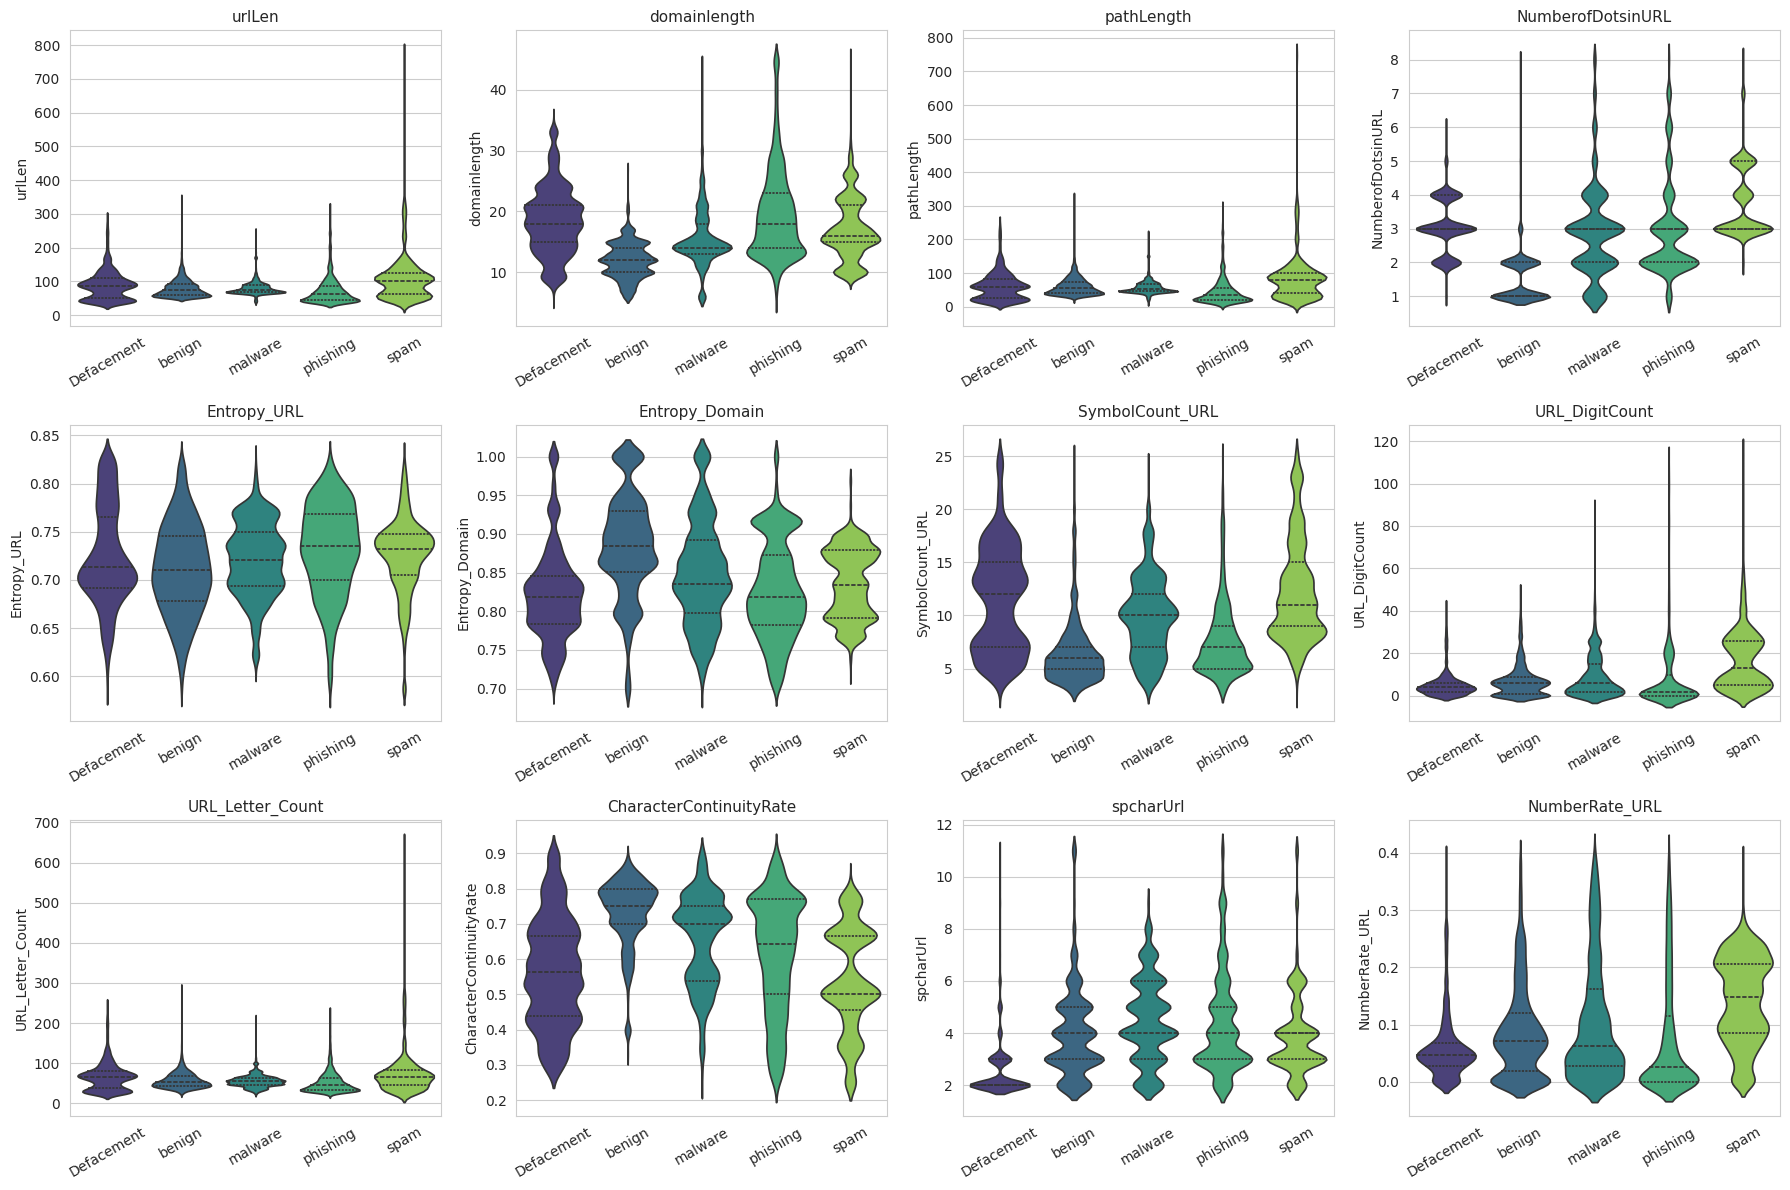

In [54]:
# Per-class violin plots for each interesting feature (dynamic grid + clean unused axes)
if not INTERESTING_FEATURES:
    print("No matching INTERESTING_FEATURES found in All.csv.")
else:
    n_cols = 4
    n_rows = int(np.ceil(len(INTERESTING_FEATURES) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feat in enumerate(INTERESTING_FEATURES):
        ax = axes[i]
        data = df_all[[feat, TARGET_COL]].dropna()
        # Clip heavy tails so the violin shape is visible
        lo, hi = data[feat].quantile([0.01, 0.99])
        data = data[(data[feat] >= lo) & (data[feat] <= hi)]
        sns.violinplot(data=data, x=TARGET_COL, y=feat, palette="viridis",
                       inner="quartile", ax=ax)
        ax.set_title(feat, fontsize=11)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)

    # Hide any extra subplot panels when feature count is not a multiple of n_cols
    for j in range(len(INTERESTING_FEATURES), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/06_feature_distributions_per_class.png")
    plt.show()

## Section 7 — Correlation structure

We look at two things:

1. **Feature-feature correlations** — flags multicollinearity (redundant features we could drop before a linear model).
2. **Feature-target association** — since the target is categorical we use the ANOVA F-statistic (`scipy.stats.f_oneway`), which measures how much class membership explains the variance of each numeric feature. Higher F → more discriminative feature.

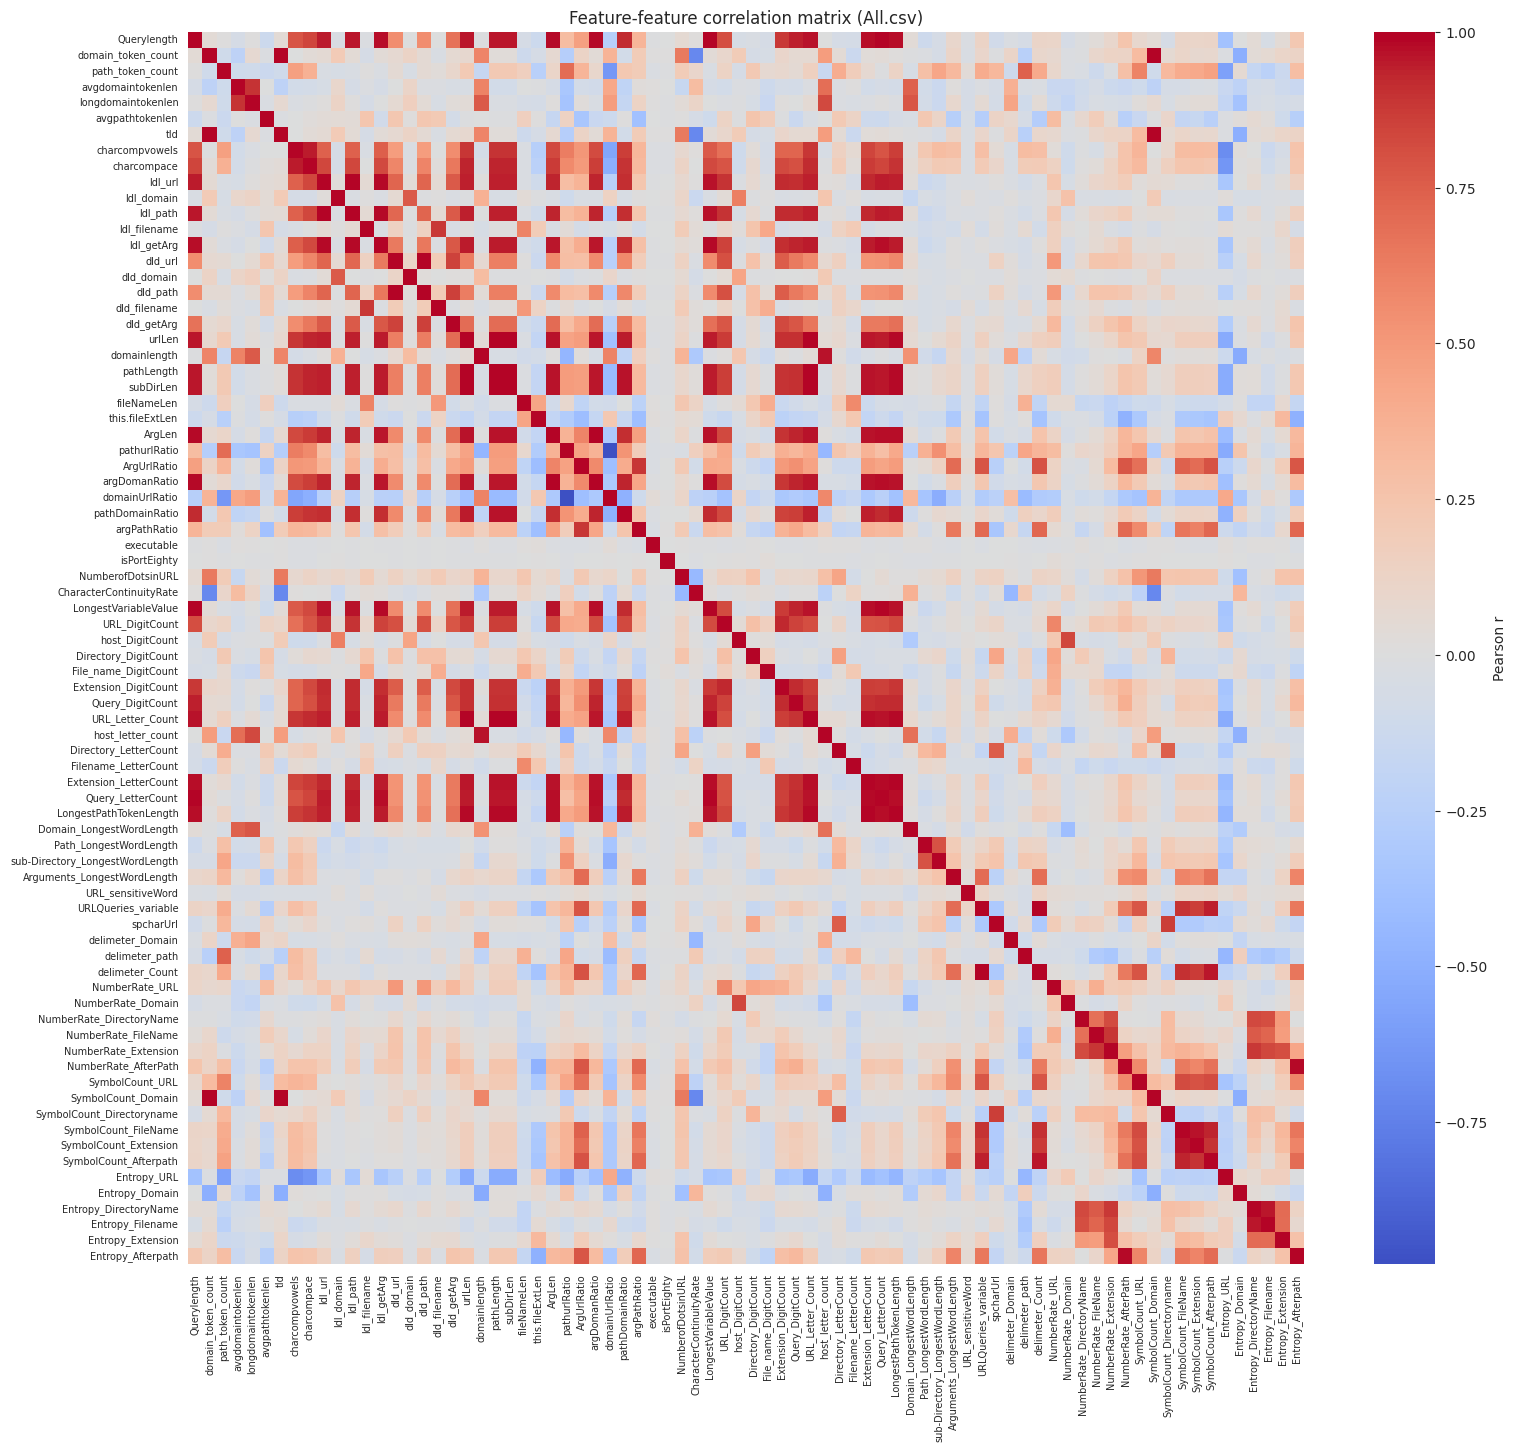

In [55]:
# Full feature correlation heatmap (no annotations — too many features)
# Drop constant cols so the matrix stays finite
cols_for_corr = [c for c in numeric_cols if c not in constant_cols]
corr = df_all[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"label": "Pearson r"},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Feature-feature correlation matrix (All.csv)")
plt.xticks(fontsize=7, rotation=90); plt.yticks(fontsize=7)
plt.savefig(f"{OUTPUT_DIR}/07_correlation_heatmap.png")
plt.show()

In [56]:
# Top correlated pairs (|r| > 0.9) — multicollinearity candidates
pairs = (
    corr.where(~np.eye(len(corr), dtype=bool))
        .stack()
        .reset_index()
        .rename(columns={"level_0": "f1", "level_1": "f2", 0: "r"})
)
pairs = pairs[pairs["f1"] < pairs["f2"]]  # de-dup (a,b)/(b,a)
top_pairs = pairs.reindex(pairs["r"].abs().sort_values(ascending=False).index).head(20)
print("Top 20 most correlated feature pairs (|r| desc):")
print(top_pairs.round(3).to_string(index=False))

Top 20 most correlated feature pairs (|r| desc):
                   f1                     f2     r
           pathLength              subDirLen 1.000
   domain_token_count                    tld 1.000
             ldl_path                ldl_url 0.999
   SymbolCount_Domain     domain_token_count 0.999
   SymbolCount_Domain                    tld 0.999
    Query_LetterCount            Querylength 0.998
            subDirLen                 urlLen 0.997
           pathLength                 urlLen 0.997
 LongestVariableValue            Querylength 0.996
             dld_path                dld_url 0.996
 LongestVariableValue      Query_LetterCount 0.995
  URLQueries_variable        delimeter_Count 0.993
               ArgLen          argDomanRatio 0.992
     URL_Letter_Count                 urlLen 0.992
     URL_Letter_Count              subDirLen 0.989
     URL_Letter_Count             pathLength 0.989
Extension_LetterCount LongestPathTokenLength 0.986
 LongestVariableValue            

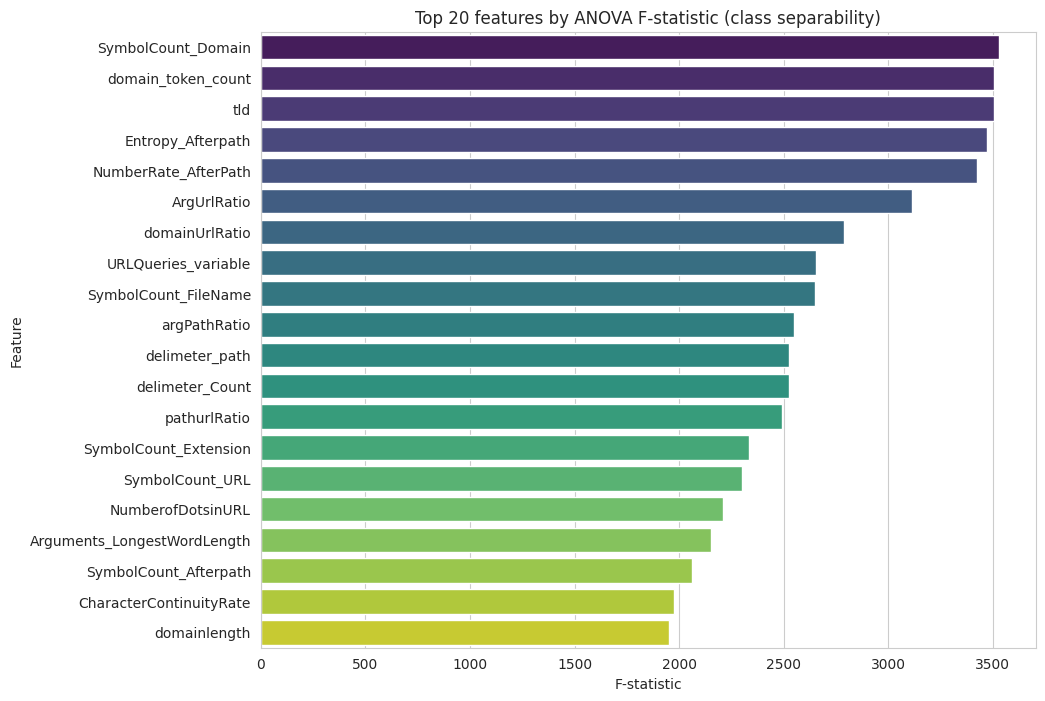

In [66]:
# ANOVA F-statistic: which features best separate the 5 classes?
def anova_f(feature: str) -> float:
    groups = []
    for _, g in df_all.groupby(TARGET_COL):
        vals = g[feature].dropna().values
        vals = vals[np.isfinite(vals)]
        if len(vals) > 1:
            groups.append(vals)

    if len(groups) < 2:
        return 0.0

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            stat = f_oneway(*groups).statistic
        return float(stat) if np.isfinite(stat) else 0.0
    except Exception:
        return 0.0

f_scores = pd.Series({c: anova_f(c) for c in cols_for_corr}).sort_values(ascending=False)
top_f = f_scores.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top_f.values, y=top_f.index, palette="viridis", ax=ax)
ax.set_title("Top 20 features by ANOVA F-statistic (class separability)")
ax.set_xlabel("F-statistic"); ax.set_ylabel("Feature")
plt.savefig(f"{OUTPUT_DIR}/07_anova_top_features.png")
plt.show()

## Section 8 — Feature-selection subsets: BestFirst vs Infogain

The two subset files come from WEKA-style feature selection run on the full feature set:

- **BestFirst** (8 features): greedy search that balances a subset's predictive power against redundancy.
- **Information Gain** (12 features): ranks features by how much they reduce class entropy.

We check their overlap and compare them against our own ANOVA top-N.

In [58]:
# Identify the feature sets (excluding the target column)
bf_features = [c for c in df_bf.columns if c != TARGET_COL]
ig_features = [c for c in df_ig.columns if c != TARGET_COL]

print(f"BestFirst features ({len(bf_features)}):   {bf_features}")
print(f"Infogain  features ({len(ig_features)}):   {ig_features}")

overlap = sorted(set(bf_features) & set(ig_features))
bf_only = sorted(set(bf_features) - set(ig_features))
ig_only = sorted(set(ig_features) - set(bf_features))
print(f"\nOverlap ({len(overlap)}): {overlap}")
print(f"BestFirst only ({len(bf_only)}): {bf_only}")
print(f"Infogain  only ({len(ig_only)}): {ig_only}")

BestFirst features (8):   ['domain_token_count', 'executable', 'NumberofDotsinURL', 'Arguments_LongestWordLength', 'NumberRate_Domain', 'NumberRate_FileName', 'NumberRate_AfterPath', 'Entropy_Domain']
Infogain  features (12):   ['avgpathtokenlen', 'pathurlRatio', 'ArgUrlRatio', 'argDomanRatio', 'domainUrlRatio', 'pathDomainRatio', 'argPathRatio', 'CharacterContinuityRate', 'NumberRate_URL', 'NumberRate_FileName', 'NumberRate_AfterPath', 'Entropy_Domain']

Overlap (3): ['Entropy_Domain', 'NumberRate_AfterPath', 'NumberRate_FileName']
BestFirst only (5): ['Arguments_LongestWordLength', 'NumberRate_Domain', 'NumberofDotsinURL', 'domain_token_count', 'executable']
Infogain  only (9): ['ArgUrlRatio', 'CharacterContinuityRate', 'NumberRate_URL', 'argDomanRatio', 'argPathRatio', 'avgpathtokenlen', 'domainUrlRatio', 'pathDomainRatio', 'pathurlRatio']


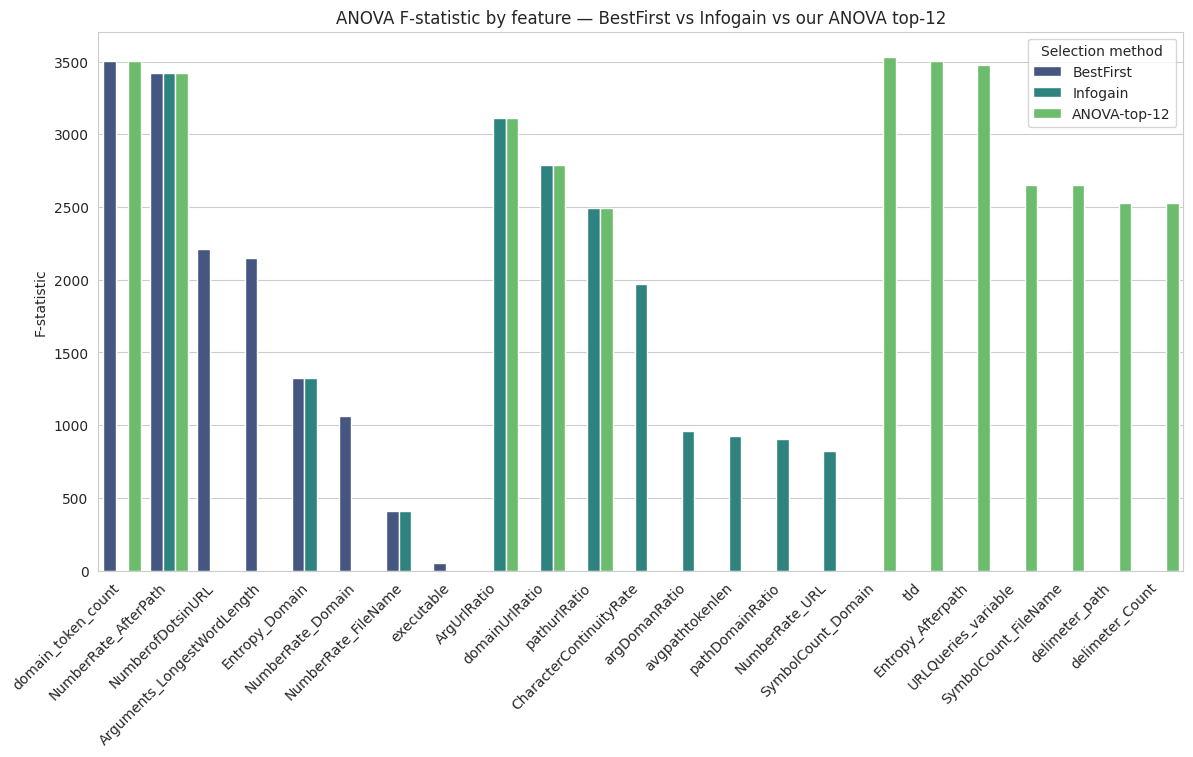

In [59]:
# Compare the three feature sets on ANOVA F-score from All.csv
def f_for(features):
    return {f: f_scores[f] for f in features if f in f_scores.index}

compare = pd.DataFrame({
    "BestFirst": pd.Series(f_for(bf_features)),
    "Infogain":  pd.Series(f_for(ig_features)),
    "ANOVA-top-12": pd.Series({f: f_scores[f] for f in f_scores.head(12).index}),
})
# Bar chart: F-score of every feature that appears in any of the three sets, colored by set membership
all_feats = sorted(set(compare.dropna(how="all").index), key=lambda f: -f_scores.get(f, 0))
plot_df = (
    compare.reindex(all_feats)
           .reset_index(names="feature")
           .melt(id_vars="feature", var_name="selection", value_name="F")
           .dropna()
)
fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=plot_df, x="feature", y="F", hue="selection", palette="viridis", ax=ax)
ax.set_title("ANOVA F-statistic by feature — BestFirst vs Infogain vs our ANOVA top-12")
ax.set_xlabel(""); ax.set_ylabel("F-statistic")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Selection method")
plt.savefig(f"{OUTPUT_DIR}/08_feature_set_comparison.png")
plt.show()

## Section 9 — Dimensionality-reduction visualization

Project the 79-dim feature space into 2D to get a visual intuition of class separability.

- **PCA** is linear and fast — the 2D projection will only show linear structure.
- **t-SNE** preserves local neighbourhoods and is much better at exposing clusters, but it is O(n²) so we sample 3,000 rows.

In [60]:
# Prepare data: drop rows with real NaN, standardize features (PCA is scale-sensitive).
# We do NOT replace -1 sentinels here — at this stage they are treated as feature values.
X_cols = [c for c in cols_for_corr]  # numeric, non-constant
data_pca = df_all.dropna(subset=X_cols + [TARGET_COL])
X = StandardScaler().fit_transform(data_pca[X_cols].values)
y = data_pca[TARGET_COL].values
print(f"PCA input: X={X.shape}, y={y.shape}")

PCA input: X=(18982, 78), y=(18982,)


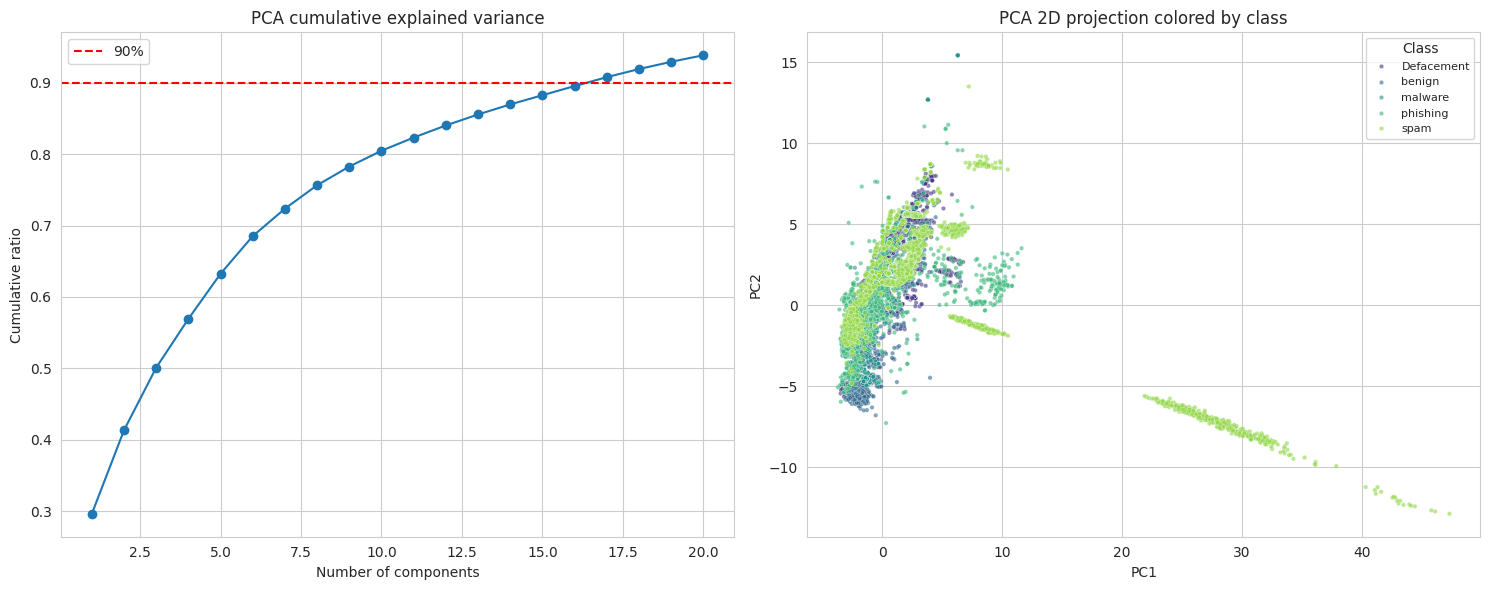

In [61]:
# PCA — explained variance curve + first-2-components scatter
pca_full = PCA(n_components=min(20, X.shape[1]), random_state=RANDOM_SEED).fit(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
             np.cumsum(pca_full.explained_variance_ratio_), marker="o")
axes[0].set_title("PCA cumulative explained variance")
axes[0].set_xlabel("Number of components"); axes[0].set_ylabel("Cumulative ratio")
axes[0].axhline(0.9, color="red", linestyle="--", label="90%"); axes[0].legend()

X_pca = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "class": y})
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="class",
                palette="viridis", s=10, alpha=0.6, ax=axes[1])
axes[1].set_title("PCA 2D projection colored by class")
axes[1].legend(title="Class", loc="best", fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_pca_projection.png")
plt.show()

t-SNE input: (3000, 78) — this takes ~30-60 seconds


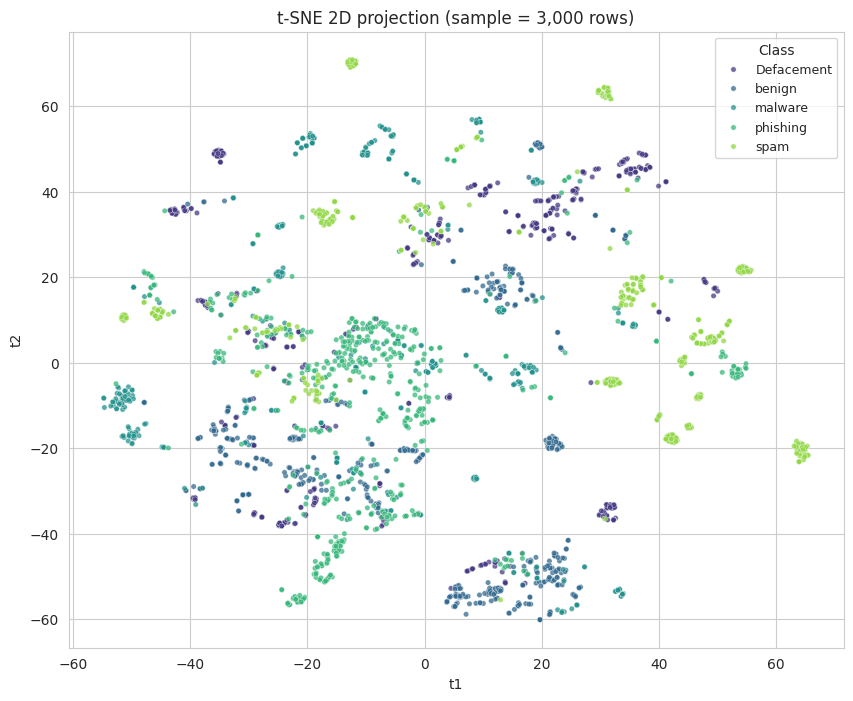

In [62]:
# t-SNE on a stratified sample (t-SNE is O(n^2) and slow on full data)
TSNE_SAMPLE = 3000
classes = sorted(data_pca[TARGET_COL].dropna().unique())
n_classes = len(classes) if len(classes) > 0 else 1
per_class_cap = max(1, TSNE_SAMPLE // n_classes)

sample_frames = []
for cls in classes:
    group = data_pca[data_pca[TARGET_COL] == cls]
    sample_frames.append(group.sample(min(len(group), per_class_cap), random_state=RANDOM_SEED))
sampled_df = pd.concat(sample_frames, axis=0) if sample_frames else data_pca.head(0)

X_sub = StandardScaler().fit_transform(sampled_df[X_cols].values)
y_sub = sampled_df[TARGET_COL].values

print(f"t-SNE input: {X_sub.shape} — this takes ~30-60 seconds")
X_tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED,
              init="pca", learning_rate="auto").fit_transform(X_sub)
tsne_df = pd.DataFrame({"t1": X_tsne[:, 0], "t2": X_tsne[:, 1], "class": y_sub})

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x="t1", y="t2", hue="class",
                palette="viridis", s=15, alpha=0.75, ax=ax)
ax.set_title(f"t-SNE 2D projection (sample = {len(sampled_df):,} rows)")
ax.legend(title="Class", loc="best", fontsize=9)
plt.savefig(f"{OUTPUT_DIR}/09_tsne_projection.png")
plt.show()

## Section 10 — Outlier detection (IQR) on top features

For each of the top-5 ANOVA features we count per-class IQR outliers. Outliers tend to concentrate in specific classes, which is itself a signal worth keeping.

Running IQR outlier detection on top-5 features: ['SymbolCount_Domain', 'tld', 'domain_token_count', 'Entropy_Afterpath', 'NumberRate_AfterPath']


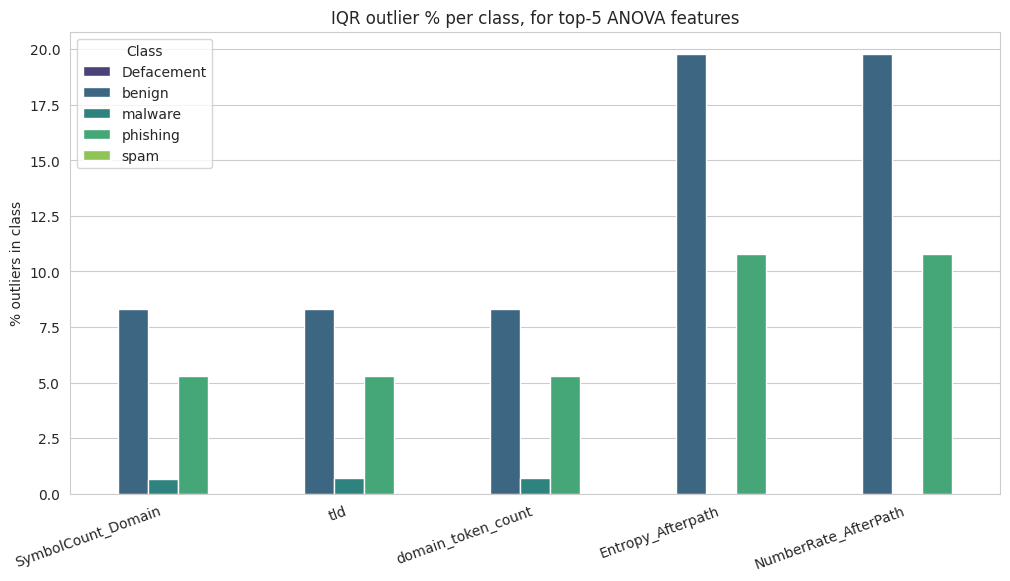

In [63]:
def iqr_outlier_mask(series: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

TOP_FEATURES = f_scores.head(5).index.tolist()
print(f"Running IQR outlier detection on top-5 features: {TOP_FEATURES}")

rows = []
for feat in TOP_FEATURES:
    for cls, group in df_all.groupby(TARGET_COL):
        s = group[feat].dropna()
        n_out = int(iqr_outlier_mask(s).sum())
        rows.append({"feature": feat, "class": cls,
                     "outlier_count": n_out,
                     "outlier_pct": n_out / len(s) * 100 if len(s) else 0.0})
outlier_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=outlier_df, x="feature", y="outlier_pct", hue="class",
            palette="viridis", ax=ax)
ax.set_title("IQR outlier % per class, for top-5 ANOVA features")
ax.set_xlabel(""); ax.set_ylabel("% outliers in class")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Class")
plt.savefig(f"{OUTPUT_DIR}/10_outliers_per_class.png")
plt.show()

## Section 11 — Save a cleaned version of `All.csv`

What this step does (and intentionally does *not* do):

- **Does:** normalize the target column name to `class`, ensure all numeric columns have numeric dtype (handles the `"NaN"` string case), drop exact duplicates, drop zero-variance constant columns.
- **Does NOT:** touch `-1` sentinels or impute NaN. Those choices belong in the preprocessing pipeline of Notebook 02 — different models prefer different strategies (tree models tolerate `-1` fine; linear/NN models prefer NaN-imputed and scaled).

In [64]:
df_clean = df_all.copy()

# Ensure all numeric-looking columns are numeric
for c in df_clean.columns:
    if c == TARGET_COL:
        continue
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

# Drop exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df_clean):,} exact-duplicate rows")

# Drop constant columns
before_cols = len(df_clean.columns)
const_cols = [c for c in df_clean.columns if c != TARGET_COL and df_clean[c].nunique(dropna=True) <= 1]
df_clean = df_clean.drop(columns=const_cols)
print(f"Dropped {len(const_cols)} constant columns: {const_cols}")
print(f"Final shape: {df_clean.shape}")

print("\nFinal class distribution:")
print(df_clean[TARGET_COL].value_counts())

df_clean.to_csv(CLEAN_PATH, index=False)
print(f"\nSaved cleaned dataset to: {CLEAN_PATH}")

Dropped 9,754 exact-duplicate rows
Dropped 1 constant columns: ['ISIpAddressInDomainName']
Final shape: (26953, 79)

Final class distribution:
class
benign        7464
phishing      7359
spam          5331
Defacement    5068
malware       1731
Name: count, dtype: int64

Saved cleaned dataset to: /home/lokmane/Desktop/url_detection_project/data/All_clean.csv


## Section 12 — Summary & next steps

**Dataset recap**

- 5 classes, ~36.7k rows, ~79 numeric features, imbalance ratio ~1.2 : 1 (much healthier than raw-URL datasets).
- `-1` is used as an "absent" sentinel across many sub-path / filename / extension features — it is a *signal*, not missing data. For tree-based models leave it as-is; for linear / neural models, replace with `NaN` and impute (median or per-class median).
- Literal string `"NaN"` in `Entropy_Extension` is already coerced to real NaN.
- No real missing values beyond that. Very few exact duplicates.

**What separates the classes (from Sections 7 & 9)**

- Entropy-based features (`Entropy_URL`, `Entropy_Domain`) and count/rate features (`NumberRate_URL`, `SymbolCount_URL`, `URL_DigitCount`, `spcharUrl`) lead the ANOVA ranking.
- PCA shows noticeable but not perfect linear separability; t-SNE reveals tighter per-class clusters, so non-linear models (tree ensembles, kernel SVM, small MLPs) should outperform pure linear ones.

**Feature subsets**

- `BestFirst` (8) and `Infogain` (12) overlap on ~5 features — mostly the same entropy / digit-rate / dots signals our ANOVA also picks.
- They make great *cheap baselines*: train any classifier on BestFirst first (8 features is almost instant) before moving to the full 79.

**Hand-off to Notebook 02 (modelling)**

1. Load `data/All_clean.csv`.
2. Stratified 70/15/15 split on `class`.
3. Preprocessing pipeline: `(-1 -> NaN) -> SimpleImputer(median) -> StandardScaler` (wrap in `sklearn.pipeline.Pipeline`).
4. Classical ML: Logistic Regression, Naive Bayes, KNN, Decision Tree, Random Forest, XGBoost, AdaBoost, RBF-SVM.
5. Evaluate with F1-macro, per-class precision/recall/F1, ROC-AUC one-vs-rest, confusion matrix. Store everything in a single `results` DataFrame.
6. Also train on the two pre-selected feature subsets to quantify the cost/benefit of the full feature set.

**Hand-off to Notebook 04 (deep learning)**

Since we're not using raw URL strings, DL on these numeric features means a small **tabular MLP / TabNet / 1D-CNN over features**. Word2Vec / BERT are dropped from the plan. If you later obtain the raw URLs, we re-introduce them as a separate text-feature branch.